In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.holtwinters import ExponentialSmoothing


In [8]:
df = pd.read_parquet(
    "../data/processed/backtest_plot_all_centers.parquet"
)


In [9]:
center_id = 31
df_c = df[df["CFGCENTROID"] == center_id]


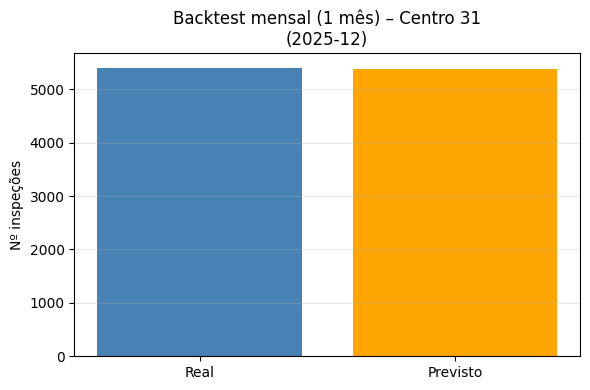

In [10]:
import matplotlib.pyplot as plt

real = df_c["real"].iloc[0]
prev = df_c["previsto"].iloc[0]
date = df_c["date"].iloc[0]

plt.figure(figsize=(6,4))
plt.bar(["Real", "Previsto"], [real, prev], color=["steelblue", "orange"])

plt.title(f"Backtest mensal (1 mês) – Centro {center_id}\n({date.strftime('%Y-%m')})")
plt.ylabel("Nº inspeções")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()



In [12]:
df = pd.read_parquet("../data/processed/monthly_all_centers.parquet")

center_id = 31
g = df[df["CFGCENTROID"] == center_id].sort_values("MONTH")
g = g.reset_index(drop=True)


In [13]:
horizon = 1
window = 12   # número de pontos de backtest

dates = []
real_vals = []
pred_vals = []

for i in range(len(g) - window, len(g)):
    train = g.iloc[:i]
    test = g.iloc[i]

    y_train = train["y"].values

    if len(y_train) < 24:   # segurança
        continue

    model = ExponentialSmoothing(
        y_train,
        trend="add",
        seasonal="add",
        seasonal_periods=12
    ).fit()

    y_hat = model.forecast(horizon)[0]

    dates.append(test["MONTH"])
    real_vals.append(test["y"])
    pred_vals.append(y_hat)


In [14]:
bt_df = pd.DataFrame({
    "date": dates,
    "real": real_vals,
    "previsto": pred_vals
})


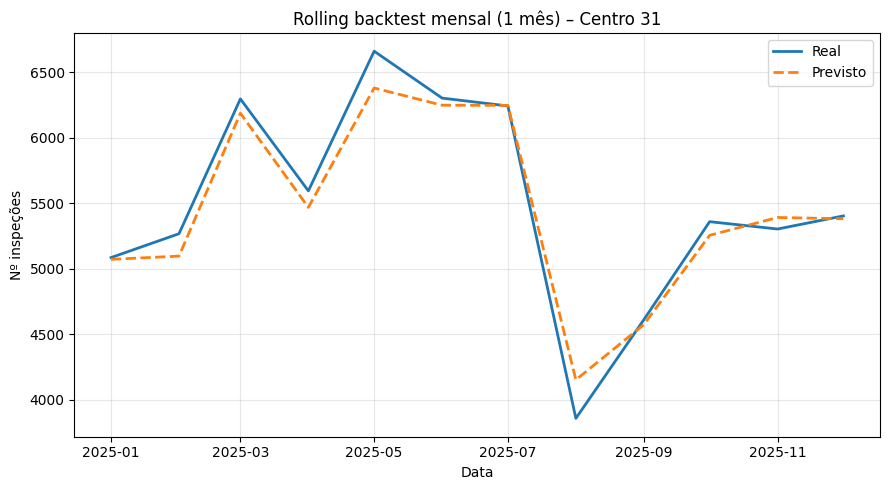

In [15]:
plt.figure(figsize=(9,5))

plt.plot(bt_df["date"], bt_df["real"], label="Real", linewidth=2)
plt.plot(bt_df["date"], bt_df["previsto"], label="Previsto", linestyle="--", linewidth=2)

plt.title(f"Rolling backtest mensal (1 mês) – Centro {center_id}")
plt.xlabel("Data")
plt.ylabel("Nº inspeções")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [16]:
wape = (
    np.sum(np.abs(bt_df["real"] - bt_df["previsto"])) /
    np.sum(np.abs(bt_df["real"]))
)

wape


np.float64(0.01976683046687276)